# Proximal Policy Optimization

In the previous notebook, we learned how to optimize a policy directly using
policy gradients.

For an actor:

$$
\pi_\theta(u|x),
$$

the policy-gradient update has the form:

$$
\nabla_\theta J=
\mathbb E
\left[
A_t
\nabla_\theta
\log
\pi_\theta(u_t|x_t)
\right].
$$

Actor-critic improved this by using a learned critic to estimate the advantage.

However, one major problem remains:

> A policy-gradient update can change the policy too much in a single step.

This notebook studies how modern policy-optimization methods control the size
of policy updates.

The progression will be:

$$
\boxed{
\text{Policy Gradient}
\rightarrow
\text{Surrogate Objective}
\rightarrow
\text{Trust Region}
\rightarrow
\text{PPO}
}
$$

## Setup

We continue with the one-dimensional vehicle model:

$$
x_t=
\begin{bmatrix}
p_t\\
v_t
\end{bmatrix},
$$

with continuous acceleration:

$$
u_t\in[u_{\min},u_{\max}].
$$

The dynamics are:

$$
p_{t+1}=
p_t+\Delta t\,v_t,
$$

$$
v_{t+1}=
v_t+\Delta t\,u_t.
$$

The control objective is velocity tracking:

$$
v_t
\rightarrow
v_{\text{ref}}.
$$

We first study PPO in this simple environment so that the policy-update
mechanism remains transparent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
DT = 0.1
V_REF = 5.0

U_MIN = -1.0
U_MAX = 1.0

EPISODE_LENGTH = 100

In [3]:
def environment_step(state, acceleration):

    position, velocity = state

    acceleration = np.clip(
        acceleration,
        U_MIN,
        U_MAX
    )

    next_position = (
        position
        + DT * velocity
    )

    next_velocity = (
        velocity
        + DT * acceleration
    )

    next_state = np.array([
        next_position,
        next_velocity
    ])

    velocity_error = (
        next_velocity - V_REF
    )

    reward = -velocity_error**2

    return next_state, reward

In [4]:
P_SCALE = 50.0
V_SCALE = 10.0


def state_to_tensor(state):

    position, velocity = state

    normalized_state = np.array([
        position / P_SCALE,
        velocity / V_SCALE
    ])

    return torch.tensor(
        normalized_state,
        dtype=torch.float32
    ).unsqueeze(0)

## 1. What Problem Is PPO Trying to Solve?

A policy-gradient method updates:

$$
\theta
\rightarrow
\theta'.
$$

This changes the policy from:

$$
\pi_\theta(u|x)
$$

to:

$$
\pi_{\theta'}(u|x).
$$

The problem is that a small change in neural-network parameters does not
necessarily imply a small change in the policy distribution.

A policy update may significantly change the probability of many actions:

$$
\pi_{\theta'}(u|x)
\not\approx
\pi_\theta(u|x).
$$

Because the policy determines which trajectories are generated, a large policy
change can suddenly move the agent into a very different data distribution.

Therefore, policy optimization needs to answer:

> How can we improve the policy while preventing a single update from changing
> it too aggressively?

## 2. Old Policy and New Policy

Suppose a trajectory was collected using the current policy:

$$
\pi_{\theta_{\text{old}}}.
$$

After collecting this experience, we want to update the policy parameters.

During optimization we therefore distinguish between:

### Behavior policy

The policy that generated the data:

$$
\pi_{\theta_{\text{old}}}(u|x).
$$

### Updated policy

The policy currently being optimized:

$$
\pi_\theta(u|x).
$$

The same collected transition can therefore be evaluated under both policies.

## 3. Probability Ratio

For a sampled state-action pair:

$$
(x_t,u_t),
$$

we compare the probability of the action under the new and old policies:

$$
\boxed{
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\text{old}}}(u_t|x_t)
}
}
$$

This ratio measures how much the policy has changed for the sampled action.

If:

$$
r_t(\theta)=1,
$$

the action has the same probability under both policies.

If:

$$
r_t(\theta)>1,
$$

the new policy makes the action more likely.

If:

$$
r_t(\theta)<1,
$$

the new policy makes the action less likely.

## 4. Probability Ratio and Advantage

The advantage tells us whether the sampled action was better or worse than
expected:

$$
A_t>0
$$

means the action should become more likely.

$$
A_t<0
$$

means the action should become less likely.

The probability ratio:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\text{old}}}(u_t|x_t)
}
$$

measures how the new policy changes the probability of that action.

Combining both gives the surrogate objective:

$$
\boxed{
L(\theta)=
\mathbb E
\left[
r_t(\theta)A_t
\right].
}
$$

## 5. The Surrogate Objective

The true reinforcement-learning objective is:

$$
J(\theta)=
\mathbb E_{\tau\sim\pi_\theta}
[R(\tau)].
$$

Evaluating this objective exactly after every candidate parameter update would
require generating new trajectories from each candidate policy.

Instead, policy optimization uses trajectories generated by the old policy:

$$
\pi_{\theta_{\text{old}}}.
$$

The probability ratio:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\text{old}}}(u_t|x_t)
}
$$

allows us to construct an approximate objective using the existing data:

$$
\boxed{
L^{\text{SUR}}(\theta)=
\mathbb E
\left[
r_t(\theta)A_t
\right].
}
$$

It is called a surrogate objective because it acts as a tractable proxy for
the true expected-return objective during policy optimization.

## 6. At the Beginning of Policy Optimization

Before any optimization step:

$$
\theta=
\theta_{\text{old}}.
$$

Therefore:

$$
\pi_\theta(u_t|x_t)=
\pi_{\theta_{\text{old}}}(u_t|x_t),
$$

which means:

$$
\boxed{
r_t(\theta)=1.
}
$$

The surrogate term therefore initially becomes:

$$
r_t(\theta)A_t=A_t.
$$

As optimization changes the policy, the probability ratio moves away from one
and records how strongly the sampled action probability has changed.

## 7. Why the Surrogate Objective Can Still Be Dangerous

The surrogate objective is:

$$
L^{\mathrm{SUR}}(\theta)=
\mathbb E
\left[
r_t(\theta)A_t
\right].
$$

If:

$$
A_t>0,
$$

the optimizer is encouraged to increase:

$$
r_t(\theta).
$$

If:

$$
A_t<0,
$$

the optimizer is encouraged to decrease:

$$
r_t(\theta).
$$

However, the surrogate objective itself does not directly prevent the new
policy from becoming very different from the old policy.

A large optimization step may therefore produce:

$$
\pi_\theta
\not\approx
\pi_{\theta_{\mathrm{old}}}.
$$

This can make the approximation based on the old trajectory unreliable.

## 8. Parameter Distance vs Policy Distance

A small change in neural-network parameters:

$$
\|\theta_{\mathrm{new}}-\theta_{\mathrm{old}}\|
$$

does not necessarily imply a small change in the policy distribution.

The quantity we actually care about is how much:

$$
\pi_{\theta_{\mathrm{new}}}(u|x)
$$

differs from:

$$
\pi_{\theta_{\mathrm{old}}}(u|x).
$$

Therefore, trust-region methods control policy change in distribution space
rather than only controlling parameter step size.

## 9. Measuring Policy Change With KL Divergence

To control how much the policy changes, we need a measure of distance between
probability distributions.

A common choice is the Kullback-Leibler divergence:

$$
\boxed{
D_{\mathrm{KL}}
\left(
\pi_{\mathrm{old}}
\|
\pi_{\mathrm{new}}
\right)
}
$$

A small KL divergence means the new policy remains close to the old policy.

A large KL divergence means the probability distribution has changed
substantially.

The trust-region idea is therefore:

$$
\boxed{
\text{improve the surrogate objective}
}
$$

while enforcing:

$$
\boxed{
D_{\mathrm{KL}}
\left(
\pi_{\mathrm{old}}
\|
\pi_{\mathrm{new}}
\right)
\le
\delta.
}
$$

## 10. Trust Region Policy Optimization

Trust Region Policy Optimization (TRPO) improves the surrogate objective while
restricting how much the policy is allowed to change.

Conceptually:

$$
\max_\theta
\quad
\mathbb E
\left[
r_t(\theta)A_t
\right]
$$

subject to:

$$
\boxed{
\mathbb E
\left[
D_{\mathrm{KL}}
\left(
\pi_{\theta_{\mathrm{old}}}
\|
\pi_\theta
\right)
\right]
\le
\delta.
}
$$

The quantity $\delta$ defines the trust region.

Inside this region, we trust the surrogate approximation.

Outside this region, the new policy has moved too far from the policy that
generated the data.

## 11. Why TRPO Is Computationally More Complicated?

TRPO formulates policy learning as a constrained optimization problem:

$$
\max_\theta
\quad
L^{\mathrm{SUR}}(\theta)
$$

subject to:

$$
D_{\mathrm{KL}}
\left(
\pi_{\mathrm{old}}
\|
\pi_\theta
\right)
\le
\delta.
$$

This constraint makes the optimization more complicated than ordinary
first-order gradient descent.

TRPO therefore uses additional approximations and second-order information to
control the update.

This motivates a simpler question:

> Can we obtain a similar conservative policy update using a standard
> first-order optimizer?

This leads to Proximal Policy Optimization.

## 12. PPO: Keep the Probability Ratio Near One

PPO replaces the explicit trust-region constraint with a simpler mechanism.

Recall the probability ratio:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\mathrm{old}}}(u_t|x_t)
}.
$$

If the new and old policies are similar:

$$
r_t(\theta)\approx1.
$$

PPO defines a clipping interval:

$$
\boxed{
1-\epsilon
\le
r_t(\theta)
\le
1+\epsilon.
}
$$

For example, if:

$$
\epsilon=0.2,
$$

the interval becomes:

$$
0.8
\le
r_t(\theta)
\le
1.2.
$$

The goal is to prevent a sampled action probability from being changed too
aggressively during one policy update.

## 13. The PPO Clipped Objective

PPO uses the clipped surrogate objective:

$$
\boxed{
L^{\mathrm{CLIP}}(\theta)=
\mathbb E
\left[
\min
\left(
r_t(\theta)A_t,
\operatorname{clip}
\left(
r_t(\theta),
1-\epsilon,
1+\epsilon
\right)
A_t
\right)
\right].
}
$$

The clipping operation restricts the benefit obtained by moving the policy too
far away from the old policy.

The key idea is:

> Once the probability ratio has changed enough in a favorable direction,
> PPO stops rewarding additional movement in that direction.

## 14. PPO Clipping for Positive Advantage

Suppose:

$$
A_t>0.
$$

The sampled action performed better than expected, so the policy should make
that action more likely.

Therefore, increasing:

$$
r_t(\theta)
$$

is desirable.

However, PPO prevents excessive increase.

If:

$$
\epsilon=0.2,
$$

then once:

$$
r_t(\theta)>1.2,
$$

the clipped objective no longer rewards further increases in the probability
of that action.

Therefore:

$$
\boxed{
A_t>0
\quad\Rightarrow\quad
\text{increase probability, but not too much}.
}
$$

## 15. PPO Clipping for Negative Advantage

Suppose:

$$
A_t<0.
$$

The sampled action performed worse than expected.

The policy should therefore reduce the probability of that action:

$$
r_t(\theta)<1.
$$

However, PPO prevents the probability from being reduced too aggressively.

For:

$$
\epsilon=0.2,
$$

once:

$$
r_t(\theta)<0.8,
$$

the clipped objective stops providing additional benefit for reducing the
probability further.

Therefore:

$$
\boxed{
A_t<0
\quad\Rightarrow\quad
\text{decrease probability, but not too much}.
}
$$

## 16. Why PPO Uses the Minimum?

The PPO objective contains:

$$
\min
\left(
r_tA_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_t
\right).
$$

The minimum selects the more conservative objective value.

This creates a pessimistic estimate of improvement.

If the policy moves too far in a direction that appears beneficial according
to the surrogate objective, the clipped term prevents the optimizer from
receiving additional benefit.

Therefore, PPO encourages improvement while discouraging excessively large
policy changes.

## 17. TRPO vs PPO

TRPO controls policy movement using an explicit constraint:

$$
D_{\mathrm{KL}}
\left(
\pi_{\mathrm{old}}
\|
\pi_{\mathrm{new}}
\right)
\le
\delta.
$$

PPO instead modifies the optimization objective using the probability ratio:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\mathrm{old}}(u_t|x_t)
}.
$$

The clipped PPO objective limits the incentive for large changes:

$$
L^{\mathrm{CLIP}}=
\mathbb E
\left[
\min
\left(
r_tA_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_t
\right)
\right].
$$

Therefore:

$$
\boxed{
\text{TRPO}
\rightarrow
\text{explicit constrained optimization}
}
$$

while:

$$
\boxed{
\text{PPO}
\rightarrow
\text{simple first-order optimization with clipping}.
}
$$

## 18. PPO Actor and Critic

PPO uses an actor-critic architecture.

The actor represents the policy:

$$
\pi_\theta(u|x),
$$

while the critic estimates the state value:

$$
V_\phi(x).
$$

For continuous control, the actor represents a Gaussian distribution:

$$
u_t
\sim
\mathcal N
\left(
\mu_\theta(x_t),
\sigma_\theta^2
\right).
$$

The critic outputs a scalar estimate:

$$
V_\phi(x_t).
$$

During rollout collection, the actor is used to sample actions and the critic
provides value estimates.

During PPO optimization, both networks are updated using the collected rollout.

In [5]:
class PPOActor(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )

        self.mean_head = nn.Linear(
            64,
            1
        )

        self.log_std = nn.Parameter(
            torch.tensor([-0.5])
        )

    def forward(self, state):

        features = self.network(
            state
        )

        mean = self.mean_head(
            features
        )

        std = torch.exp(
            self.log_std
        )

        return mean, std

In [6]:
class PPOCritic(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):

        return self.network(
            state
        ).squeeze(-1)

## 19. Sampling Actions and Storing Old Log-Probabilities

During rollout collection, the policy is frozen and acts as the old policy:

$$
\pi_{\theta_{\text{old}}}.
$$

For each state:

$$
x_t,
$$

we sample an action:

$$
u_t
\sim
\pi_{\theta_{\text{old}}}(\cdot|x_t).
$$

We store:

$$
\log
\pi_{\theta_{\text{old}}}(u_t|x_t).
$$

Later, during optimization, the same stored state-action pair is evaluated under
the updated policy:

$$
\log
\pi_\theta(u_t|x_t).
$$

The PPO ratio is then:

$$
r_t(\theta)=
\exp
\left(
\log\pi_\theta(u_t|x_t)-
\log\pi_{\theta_{\text{old}}}(u_t|x_t)
\right).
$$

In [7]:
def sample_ppo_action(
    actor,
    critic,
    state
):

    state_tensor = state_to_tensor(
        state
    )

    with torch.no_grad():

        mean, std = actor(
            state_tensor
        )

        distribution = torch.distributions.Normal(
            mean,
            std
        )

        raw_action = distribution.sample()

        log_prob = distribution.log_prob(
            raw_action
        ).sum(dim=-1)

        value = critic(
            state_tensor
        )

    action = torch.tanh(
        raw_action
    )

    acceleration = action.item()

    return (
        acceleration,
        raw_action.item(),
        log_prob.item(),
        value.item()
    )

## 20. Why Store the Raw Gaussian Action?

The Gaussian actor first samples an unconstrained variable:

$$
z_t
\sim
\mathcal N(\mu_\theta(x_t),\sigma^2).
$$

The bounded control is then obtained using:

$$
u_t=
\tanh(z_t).
$$

The Gaussian log-probability is naturally evaluated at:

$$
z_t,
$$

not directly at the bounded action $u_t$.

Therefore, during rollout collection we store both:

$$
z_t
$$

and:

$$
u_t=\tanh(z_t).
$$

The environment receives:

$$
u_t,
$$

while PPO optimization can reuse the stored latent Gaussian sample:

$$
z_t.
$$

## 21. PPO Rollout Buffer

PPO first collects a batch of experience using the old policy.

For every transition, we store:

$$
x_t
$$

$$
u_t
$$

$$
r_{t+1}
$$

$$
V_\phi(x_t)
$$

$$
\log\pi_{\theta_{\text{old}}}(u_t|x_t)
$$

and whether the trajectory has terminated.

The rollout buffer separates:

$$
\text{data collection}
$$

from:

$$
\text{policy optimization}.
$$

After the rollout is collected, PPO reuses the same data for several gradient
updates.

In [8]:
class RolloutBuffer:

    def __init__(self):

        self.states = []
        self.actions = []
        self.raw_actions = []
        self.rewards = []
        self.values = []
        self.log_probs = []
        self.dones = []

    def add(
        self,
        state,
        action,
        raw_action,
        reward,
        value,
        log_prob,
        done
    ):

        self.states.append(
            state.copy()
        )

        self.actions.append(
            action
        )

        self.raw_actions.append(
            raw_action
        )

        self.rewards.append(
            reward
        )

        self.values.append(
            value
        )

        self.log_probs.append(
            log_prob
        )

        self.dones.append(
            done
        )

    def clear(self):

        self.__init__()

## 22. Collecting a Rollout

A PPO rollout is generated entirely using the current policy:

$$
\pi_{\theta_{\text{old}}}.
$$

During rollout collection, the policy parameters remain fixed.

For each step:

1. Observe the state.
2. Sample an action.
3. Store the old log-probability.
4. Store the critic value estimate.
5. Execute the action.
6. Store reward and next transition information.

Only after the rollout is complete do we begin PPO optimization.

## 23. Why PPO Separates Rollout Collection and Optimization?

In one-step actor-critic, the sequence was:

$$
\text{transition}
\rightarrow
\text{update actor and critic}.
$$

PPO instead uses:

$$
\text{collect rollout}
\rightarrow
\text{freeze old probabilities}
\rightarrow
\text{perform multiple optimization steps}.
$$

This separation is necessary because PPO compares the updated policy against the
policy that generated the data.

The stored old log-probability:

$$
\log
\pi_{\theta_{\text{old}}}(u_t|x_t)
$$

remains fixed during optimization.

The new log-probability:

$$
\log
\pi_\theta(u_t|x_t)
$$

changes as the actor parameters are updated.

## 24. From TD Advantage to Generalized Advantage Estimation

A one-step advantage estimate is:

$$
\delta_t=
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t).
$$

This has relatively low variance but relies strongly on the critic.

A Monte Carlo advantage is:

$$
G_t-V(x_t).
$$

This uses the complete future trajectory and can have higher variance.

**Generalized Advantage Estimation (GAE)** combines multiple temporal-difference
errors to interpolate between these two extremes.

## 25. Generalized Advantage Estimation

Generalized Advantage Estimation constructs the advantage from multiple
temporal-difference errors.

The one-step TD error is:

$$
\delta_t=
r_{t+1}+
\gamma V(x_{t+1})-
V(x_t).
$$

GAE defines:

$$
\boxed{
\hat A_t=
\delta_t
+
\gamma\lambda\delta_{t+1}
+
(\gamma\lambda)^2\delta_{t+2}
+
\cdots
}
$$

or:

$$
\boxed{
\hat A_t=
\sum_{l=0}^{T-t-1}
(\gamma\lambda)^l
\delta_{t+l}.
}
$$

The parameter:

$$
\lambda\in[0,1]
$$

controls how strongly future TD errors contribute to the current advantage
estimate.

## 26. The Role of Lambda in GAE

The GAE parameter:

$$
\lambda
$$

controls the trade-off between short-horizon bootstrapping and long-horizon
return information.

If:

$$
\lambda=0,
$$

then:

$$
\hat A_t=
\delta_t.
$$

This corresponds to a one-step TD advantage.

As:

$$
\lambda\rightarrow1,
$$

more future TD errors contribute to the estimate.

Conceptually:

$$
\boxed{
\lambda\text{ small}
\rightarrow
\text{more bootstrapping, lower variance}
}
$$

$$
\boxed{
\lambda\text{ large}
\rightarrow
\text{more trajectory information, lower bias}
}
$$

GAE therefore provides a bias-variance trade-off for the advantage estimate.

## 27. Recursive GAE Calculation

GAE can be calculated efficiently using the backward recursion:

$$
\boxed{
\hat A_t=
\delta_t
+
\gamma\lambda
(1-d_t)
\hat A_{t+1}.
}
$$

The terminal indicator:

$$
d_t
$$

prevents bootstrapping beyond the end of a trajectory.

This backward computation is only an efficient way to process already collected
experience.

**NOTE:** It is not a dynamic-programming backward optimization.

## 28. GAE Implementation

In [9]:
def compute_gae(
    rewards,
    values,
    dones,
    last_value,
    gamma=0.99,
    gae_lambda=0.95
):

    advantages = np.zeros(
        len(rewards),
        dtype=np.float32
    )

    gae = 0.0

    for t in reversed(
        range(len(rewards))
    ):

        if t == len(rewards) - 1:

            next_value = last_value

        else:

            next_value = values[
                t + 1
            ]

        non_terminal = (
            1.0 - float(dones[t])
        )

        delta = (
            rewards[t]
            + gamma
            * next_value
            * non_terminal
            - values[t]
        )

        gae = (
            delta
            + gamma
            * gae_lambda
            * non_terminal
            * gae
        )

        advantages[t] = gae

    returns = (
        advantages
        + np.array(
            values,
            dtype=np.float32
        )
    )

    return (
        advantages,
        returns
    )

## 29. Value Targets From the Advantage Estimate

By definition:

$$
A^\pi(x_t,u_t)=
Q^\pi(x_t,u_t)-
V^\pi(x_t).
$$

Therefore:

$$
Q^\pi(x_t,u_t)=
A^\pi(x_t,u_t)
+
V^\pi(x_t).
$$

Using the estimated advantage:

$$
\hat A_t,
$$

we construct a value target:

$$
\boxed{
\hat R_t=
\hat A_t
+
V_\phi(x_t).
}
$$

The actor uses:

$$
\hat A_t,
$$

while the critic is trained toward:

$$
\hat R_t.
$$

## 30. Preparing the PPO Training Data

After collecting a rollout and computing:

$$
\hat A_t
$$

and:

$$
\hat R_t,
$$

we convert the stored rollout into tensors.

The PPO update requires:

$$
x_t,
\quad
z_t,
\quad
\log\pi_{\text{old}}(z_t|x_t),
\quad
\hat A_t,
\quad
\hat R_t.
$$

The old log-probabilities remain fixed during optimization.

The actor and critic are then updated using the same rollout data for several
epochs.

In [10]:
def prepare_ppo_tensors(
    buffer,
    advantages,
    returns
):

    states = np.array(
        buffer.states,
        dtype=np.float32
    )

    states[:, 0] /= P_SCALE
    states[:, 1] /= V_SCALE

    states = torch.tensor(
        states,
        dtype=torch.float32
    )

    raw_actions = torch.tensor(
        buffer.raw_actions,
        dtype=torch.float32
    ).unsqueeze(1)

    old_log_probs = torch.tensor(
        buffer.log_probs,
        dtype=torch.float32
    )

    advantages = torch.tensor(
        advantages,
        dtype=torch.float32
    )

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    return (
        states,
        raw_actions,
        old_log_probs,
        advantages,
        returns
    )

## 31. Advantage Normalization

The magnitude of the advantage estimates can vary significantly between
rollouts.

A common practical step is to normalize them:

$$
\boxed{
\hat A_t
\leftarrow
\frac{
\hat A_t-\mu_A
}{
\sigma_A+\epsilon
}
}
$$

This produces advantages with approximately zero mean and unit variance.

The sign and relative ordering of the advantages are preserved, while the
gradient scale becomes more consistent during optimization.

In [11]:
def normalize_advantages(
    advantages
):

    return (
        advantages
        - advantages.mean()
    ) / (
        advantages.std()
        + 1e-8
    )

## 32. Evaluating Stored Actions Under the Current Policy

The rollout was collected using:

$$
\pi_{\theta_{\text{old}}}.
$$

During optimization, the actor parameters change.

For each stored state-action pair:

$$
(x_t,z_t),
$$

we evaluate the same latent Gaussian action under the current policy:

$$
\log
\pi_\theta(z_t|x_t).
$$

This allows us to compare the current policy with the policy that generated the
data.

In [12]:
def evaluate_actions(
    actor,
    states,
    raw_actions
):

    mean, std = actor(
        states
    )

    distribution = torch.distributions.Normal(
        mean,
        std
    )

    log_probs = distribution.log_prob(
        raw_actions
    ).sum(dim=-1)

    entropy = distribution.entropy().sum(
        dim=-1
    )

    return (
        log_probs,
        entropy
    )

## 33. PPO Probability Ratio

The PPO probability ratio is:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\text{old}}}(u_t|x_t)
}.
$$

Using log-probabilities:

$$
\boxed{
r_t(\theta)=
\exp
\left(
\log\pi_\theta(u_t|x_t)-
\log\pi_{\theta_{\text{old}}}(u_t|x_t)
\right).
}
$$

At the start of optimization:

$$
r_t(\theta)\approx1.
$$

As the actor changes, the ratio moves away from one.

## 34. PPO Clipped Actor Loss

The PPO clipped objective is:

$$
L^{\mathrm{CLIP}}(\theta)=
\mathbb E
\left[
\min
\left(
r_t(\theta)\hat A_t,
\operatorname{clip}
\left(
r_t(\theta),
1-\epsilon,
1+\epsilon
\right)
\hat A_t
\right)
\right].
$$

Since PyTorch minimizes losses, the actor loss is:

$$
\boxed{
L_{\text{actor}}=-
L^{\mathrm{CLIP}}(\theta).
}
$$

In [13]:
def ppo_actor_loss(
    new_log_probs,
    old_log_probs,
    advantages,
    clip_epsilon=0.2
):

    ratio = torch.exp(
        new_log_probs
        - old_log_probs
    )

    unclipped_objective = (
        ratio
        * advantages
    )

    clipped_ratio = torch.clamp(
        ratio,
        1.0 - clip_epsilon,
        1.0 + clip_epsilon
    )

    clipped_objective = (
        clipped_ratio
        * advantages
    )

    actor_loss = -torch.mean(
        torch.minimum(
            unclipped_objective,
            clipped_objective
        )
    )

    return (
        actor_loss,
        ratio
    )

## 35. PPO Critic Loss

The critic predicts:

$$
V_\phi(x_t).
$$

The value target is:

$$
\hat R_t.
$$

Therefore, the critic minimizes:

$$
\boxed{
L_{\text{critic}}=
\mathbb E
\left[
\left(
V_\phi(x_t)-
\hat R_t
\right)^2
\right].
}
$$

The critic therefore continues to solve a prediction problem while the actor
performs policy improvement.

In [14]:
def ppo_critic_loss(
    critic,
    states,
    returns
):

    predicted_values = critic(
        states
    )

    critic_loss = torch.mean(
        (
            predicted_values
            - returns
        ) ** 2
    )

    return critic_loss

## 36. Entropy Bonus

The policy entropy measures how uncertain or spread out the action distribution
is.

A high-entropy policy explores more.

A very low-entropy policy becomes nearly deterministic.

PPO commonly includes an entropy bonus:

$$
H(\pi_\theta).
$$

The optimization objective can therefore reward some amount of exploration.

When expressed as a loss:

$$
\boxed{
L=
L_{\text{actor}}+
c_v L_{\text{critic}}-
c_e H(\pi_\theta)
}
$$

where:

- $c_v$ weights the critic loss,
- $c_e$ controls the entropy bonus.

## 37. Combined PPO Objective

The practical PPO objective combines three components:

### Actor loss

$$
L_{\text{actor}}
$$

from the clipped surrogate objective.

### Critic loss

$$
L_{\text{critic}}
$$

for value-function learning.

### Entropy bonus

$$
H(\pi_\theta)
$$

to encourage continued exploration.

The combined loss is:

$$
\boxed{
L_{\text{PPO}}=
L_{\text{actor}}+
c_v L_{\text{critic}}-
c_e H(\pi_\theta).
}
$$

In [15]:
def ppo_update(
    actor,
    critic,
    actor_optimizer,
    critic_optimizer,
    states,
    raw_actions,
    old_log_probs,
    advantages,
    returns,
    clip_epsilon=0.2,
    entropy_coef=0.01
):

    new_log_probs, entropy = evaluate_actions(
        actor,
        states,
        raw_actions
    )

    actor_loss, ratio = ppo_actor_loss(
        new_log_probs,
        old_log_probs,
        advantages,
        clip_epsilon
    )

    entropy_bonus = entropy.mean()

    total_actor_loss = (
        actor_loss
        - entropy_coef
        * entropy_bonus
    )

    actor_optimizer.zero_grad()

    total_actor_loss.backward()

    actor_optimizer.step()

    critic_loss = ppo_critic_loss(
        critic,
        states,
        returns
    )

    critic_optimizer.zero_grad()

    critic_loss.backward()

    critic_optimizer.step()

    return {
        "actor_loss": actor_loss.item(),
        "critic_loss": critic_loss.item(),
        "entropy": entropy_bonus.item(),
        "ratio_mean": ratio.mean().item()
    }

## 39. Multiple Optimization Epochs

The rollout is generated once using:

$$
\pi_{\theta_{\text{old}}}.
$$

The stored quantity:

$$
\log
\pi_{\theta_{\text{old}}}(u_t|x_t)
$$

remains fixed during PPO optimization.

The current actor:

$$
\pi_\theta
$$

can therefore be updated several times using the same rollout.

After each optimization step:

$$
\pi_\theta
$$

changes, so the probability ratio:

$$
r_t(\theta)
$$

also changes.

PPO clipping limits the incentive for these repeated optimization steps to move
the policy excessively far from the rollout policy.

In [16]:
def optimize_ppo(
    actor,
    critic,
    actor_optimizer,
    critic_optimizer,
    buffer,
    advantages,
    returns,
    n_epochs=10,
    clip_epsilon=0.2,
    entropy_coef=0.01
):

    (
        states,
        raw_actions,
        old_log_probs,
        advantages,
        returns
    ) = prepare_ppo_tensors(
        buffer,
        advantages,
        returns
    )

    advantages = normalize_advantages(
        advantages
    )

    metrics = []

    for _ in range(
        n_epochs
    ):

        result = ppo_update(
            actor,
            critic,
            actor_optimizer,
            critic_optimizer,
            states,
            raw_actions,
            old_log_probs,
            advantages,
            returns,
            clip_epsilon,
            entropy_coef
        )

        metrics.append(
            result
        )

    return metrics

## 41. One Complete PPO Iteration

A PPO iteration consists of two phases.

### Phase 1 — Rollout Collection

Freeze the current actor and collect experience:

$$
\pi_{\theta_{\text{old}}}
\rightarrow
\{
x_t,
u_t,
r_t,
V_t,
\log\pi_{\text{old}}
\}.
$$

Then calculate:

$$
\hat A_t
$$

using GAE and construct:

$$
\hat R_t.
$$

### Phase 2 — Policy Optimization

Reuse the rollout for several gradient updates.

For every update:

1. Evaluate the stored actions under the current actor.
2. Compute:

$$
r_t(\theta).
$$

3. Calculate the clipped actor loss.
4. Update the actor.
5. Train the critic toward:

$$
\hat R_t.
$$

After several epochs, discard the rollout and collect new data using the updated
policy.

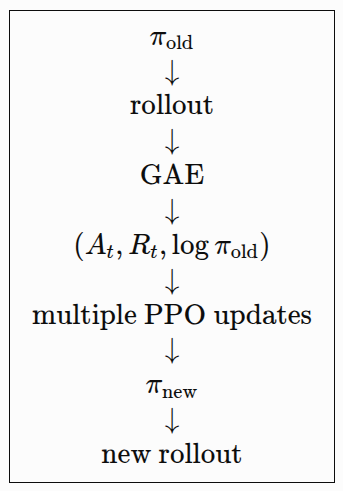

## PPO Helper Functions

Before training, we collect the helper functions required by the PPO training
loop in one place.

The rollout function generates experience using the current policy:

$$
\pi_{\theta_{\mathrm{old}}},
$$

and stores the states, actions, rewards, value estimates, and old
log-probabilities required for the PPO update.

In [20]:
def collect_rollout(
    actor,
    critic,
    episode_length=EPISODE_LENGTH
):
    buffer = RolloutBuffer()

    # Initial state: position = 0, velocity = 0
    state = np.array(
        [0.0, 0.0],
        dtype=np.float32
    )

    episode_return = 0.0

    for t in range(episode_length):

        # Sample action from current policy
        (
            action,
            raw_action,
            log_prob,
            value
        ) = sample_ppo_action(
            actor,
            critic,
            state
        )

        # Environment transition
        next_state, reward = environment_step(
            state,
            action
        )

        # Fixed-horizon termination
        done = (t == episode_length - 1)

        # Store transition
        buffer.add(
            state=state,
            action=action,
            raw_action=raw_action,
            reward=reward,
            value=value,
            log_prob=log_prob,
            done=done
        )

        episode_return += reward

        state = next_state

    return (
        buffer,
        episode_return,
        state
    )

## 42. Initialize the PPO Agent

We now initialize the PPO actor, critic, and their optimizers.

The actor parameters:

$$
\theta
$$

represent the policy:

$$
\pi_\theta(u|x),
$$

while the critic parameters:

$$
\phi
$$

represent:

$$
V_\phi(x).
$$

The two networks are optimized separately so that the policy-improvement and
value-estimation processes remain easy to inspect.

In [21]:
actor = PPOActor()
critic = PPOCritic()

actor_optimizer = optim.Adam(
    actor.parameters(),
    lr=3e-4
)

critic_optimizer = optim.Adam(
    critic.parameters(),
    lr=1e-3
)

## 43. PPO Training Hyperparameters

PPO introduces several important hyperparameters.

The discount factor:

$$
\gamma
$$

determines how strongly future rewards contribute.

The GAE parameter:

$$
\lambda
$$

controls the bias-variance trade-off in advantage estimation.

The clipping parameter:

$$
\epsilon
$$

controls how far the policy ratio can move before additional improvement is no
longer rewarded.

Finally, PPO performs several optimization epochs using each collected rollout.

In [22]:
GAMMA = 0.99
GAE_LAMBDA = 0.95

CLIP_EPSILON = 0.2
ENTROPY_COEF = 0.01

PPO_EPOCHS = 10

N_ITERATIONS = 500

## 44. Complete PPO Training Loop

Each PPO training iteration performs the following sequence:

$$
\boxed{
\text{collect rollout}
\rightarrow
\text{compute GAE}
\rightarrow
\text{construct value targets}
\rightarrow
\text{optimize actor and critic}
}
$$

The updated actor is then used to collect the next rollout.

Because the episode terminates at the end of the fixed horizon, the terminal
bootstrap value is:

$$
V(x_{T+1})=0.
$$

In [23]:
episode_returns = []

actor_losses = []
critic_losses = []
entropy_history = []
ratio_history = []

for iteration in range(N_ITERATIONS):

    # --------------------------------
    # 1. Collect rollout
    # --------------------------------

    (
        buffer,
        episode_return,
        final_state
    ) = collect_rollout(
        actor,
        critic
    )

    # Fixed-horizon episode terminates
    last_value = 0.0

    # --------------------------------
    # 2. Compute GAE and value targets
    # --------------------------------

    advantages, returns = compute_gae(
        rewards=buffer.rewards,
        values=buffer.values,
        dones=buffer.dones,
        last_value=last_value,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA
    )

    # --------------------------------
    # 3. PPO optimization
    # --------------------------------

    metrics = optimize_ppo(
        actor=actor,
        critic=critic,
        actor_optimizer=actor_optimizer,
        critic_optimizer=critic_optimizer,
        buffer=buffer,
        advantages=advantages,
        returns=returns,
        n_epochs=PPO_EPOCHS,
        clip_epsilon=CLIP_EPSILON,
        entropy_coef=ENTROPY_COEF
    )

    # --------------------------------
    # 4. Store diagnostics
    # --------------------------------

    episode_returns.append(
        episode_return
    )

    actor_losses.append(
        np.mean([
            m["actor_loss"]
            for m in metrics
        ])
    )

    critic_losses.append(
        np.mean([
            m["critic_loss"]
            for m in metrics
        ])
    )

    entropy_history.append(
        np.mean([
            m["entropy"]
            for m in metrics
        ])
    )

    ratio_history.append(
        np.mean([
            m["ratio_mean"]
            for m in metrics
        ])
    )

## 45. Visualizing PPO Training

The episode return provides a simple measure of whether the learned controller is
improving.

Because the reward penalizes velocity-tracking error:

$$
r_t=-
(v_{t+1}-v_{\mathrm{ref}})^2,
$$

a larger return means that the vehicle is spending more time close to the
desired velocity.

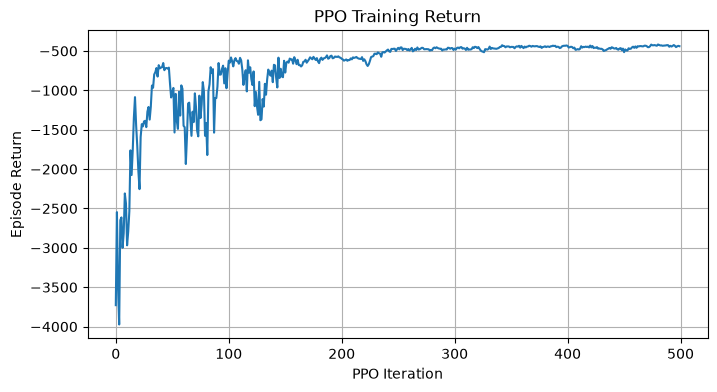

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(
    episode_returns
)

plt.xlabel(
    "PPO Iteration"
)

plt.ylabel(
    "Episode Return"
)

plt.title(
    "PPO Training Return"
)

plt.grid()

plt.show()

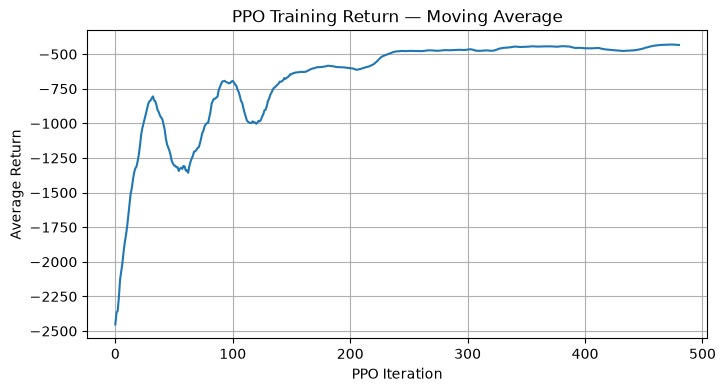

In [25]:
window = 20

moving_average = np.convolve(
    episode_returns,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 4))

plt.plot(
    moving_average
)

plt.xlabel(
    "PPO Iteration"
)

plt.ylabel(
    "Average Return"
)

plt.title(
    "PPO Training Return — Moving Average"
)

plt.grid()

plt.show()

## 46. Actor and Critic Training Diagnostics

The actor and critic optimize different objectives.

The actor minimizes the negative clipped PPO objective:

$$
L_{\mathrm{actor}}.
$$

The critic minimizes the value prediction error:

$$
L_{\mathrm{critic}}=
\mathbb E
\left[
(V_\phi(x_t)-\hat R_t)^2
\right].
$$

Unlike supervised learning, a monotonically decreasing actor loss is not
expected because the training data and policy change after every rollout.

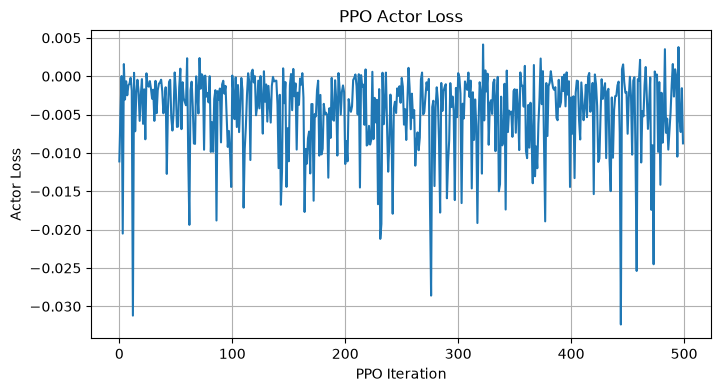

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    actor_losses
)

plt.xlabel(
    "PPO Iteration"
)

plt.ylabel(
    "Actor Loss"
)

plt.title(
    "PPO Actor Loss"
)

plt.grid()

plt.show()

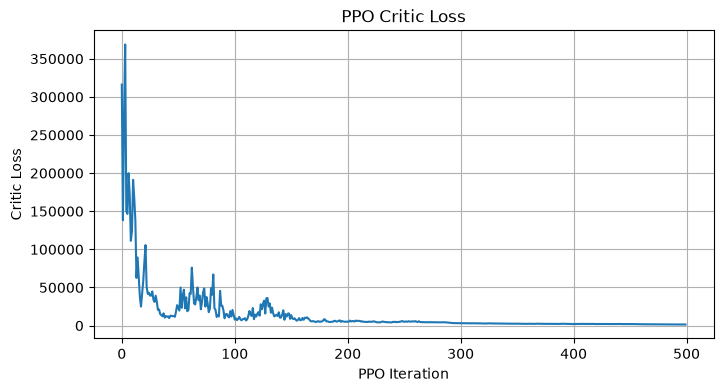

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(
    critic_losses
)

plt.xlabel(
    "PPO Iteration"
)

plt.ylabel(
    "Critic Loss"
)

plt.title(
    "PPO Critic Loss"
)

plt.grid()

plt.show()

## 47. Deterministic PPO Evaluation

During training, PPO uses a stochastic policy:

$$
z_t
\sim
\mathcal N
\left(
\mu_\theta(x_t),
\sigma^2
\right).
$$

For deterministic evaluation, exploration is unnecessary.

We therefore use:

$$
z_t=
\mu_\theta(x_t),
$$

and execute:

$$
\boxed{
u_t=
\tanh
\left(
\mu_\theta(x_t)
\right).
}
$$

This gives the action preferred by the learned policy without stochastic
exploration.

In [28]:
def deterministic_ppo_action(
    actor,
    state
):

    state_tensor = state_to_tensor(
        state
    )

    with torch.no_grad():

        mean, std = actor(
            state_tensor
        )

        action = torch.tanh(
            mean
        )

    return action.item()

In [29]:
state = np.array([
    0.0,
    0.0
])

positions = []
velocities = []
actions = []

for t in range(
    EPISODE_LENGTH
):

    action = deterministic_ppo_action(
        actor,
        state
    )

    positions.append(
        state[0]
    )

    velocities.append(
        state[1]
    )

    actions.append(
        action
    )

    state, reward = environment_step(
        state,
        action
    )

## 49. Evaluating Velocity Tracking

The main control objective is:

$$
v_t
\rightarrow
v_{\mathrm{ref}}.
$$

A successful PPO policy should accelerate the vehicle when:

$$
v_t<v_{\mathrm{ref}},
$$

and reduce acceleration as the velocity approaches the desired value.

Unlike MPC, this behavior is no longer obtained by solving an optimization
problem online.

It is encoded directly in the learned neural-network policy.

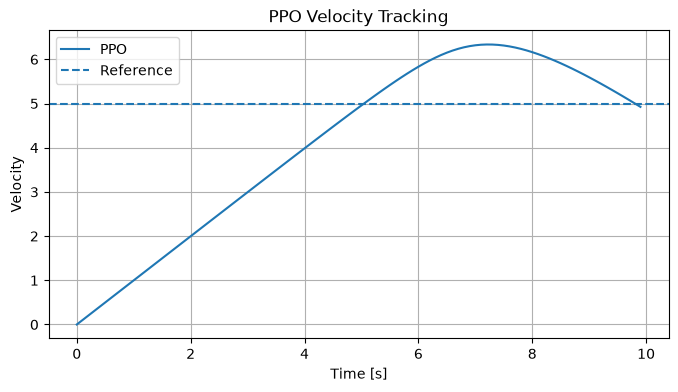

In [30]:
time = np.arange(
    EPISODE_LENGTH
) * DT

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    velocities,
    label="PPO"
)

plt.axhline(
    V_REF,
    linestyle="--",
    label="Reference"
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Velocity"
)

plt.title(
    "PPO Velocity Tracking"
)

plt.legend()

plt.grid()

plt.show()

## 50. Learned Control Signal

The PPO actor directly generates the control command:

$$
u_t=\pi_\theta(x_t).
$$

For our bounded policy:

$$
u_t=
\tanh
\left(
\mu_\theta(x_t)
\right),
$$

which guarantees:

$$
-1<u_t<1.
$$

The resulting control signal shows how the learned feedback policy responds as
the vehicle approaches the target velocity.

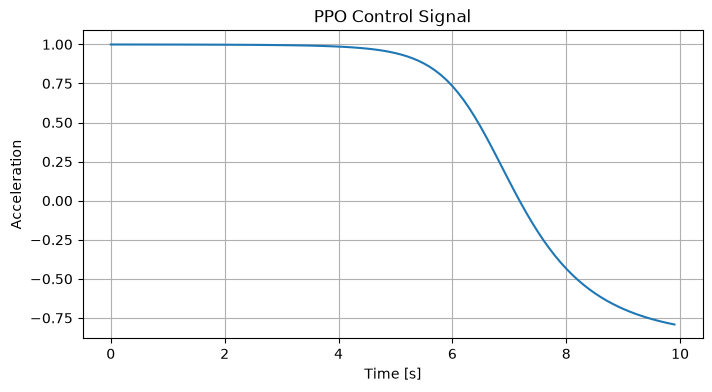

In [31]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    actions
)

plt.xlabel(
    "Time [s]"
)

plt.ylabel(
    "Acceleration"
)

plt.title(
    "PPO Control Signal"
)

plt.grid()

plt.show()

## 51. PPO as a Learned Feedback Controller

After training, the actor represents an approximate feedback control law:

$$
\boxed{
u=
\pi_\theta(x).
}
$$

We can inspect this feedback law by fixing position and varying velocity.

This allows us to visualize how the learned controller maps state to control
without running a complete trajectory.

In [32]:
velocity_grid = np.linspace(
    0.0,
    8.0,
    100
)

policy_actions = []

for velocity in velocity_grid:

    state = np.array([
        0.0,
        velocity
    ])

    action = deterministic_ppo_action(
        actor,
        state
    )

    policy_actions.append(
        action
    )

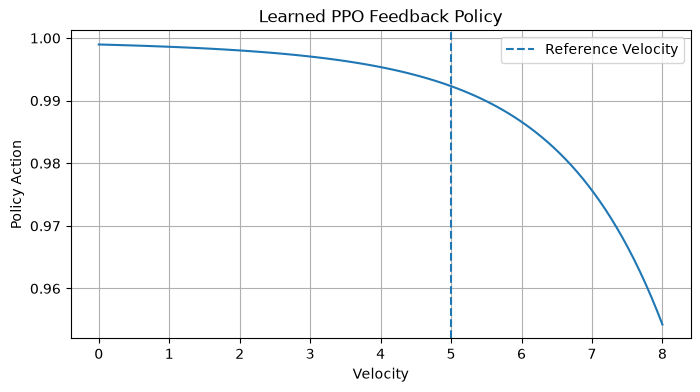

In [33]:
plt.figure(figsize=(8, 4))

plt.plot(
    velocity_grid,
    policy_actions
)

plt.axvline(
    V_REF,
    linestyle="--",
    label="Reference Velocity"
)

plt.xlabel(
    "Velocity"
)

plt.ylabel(
    "Policy Action"
)

plt.title(
    "Learned PPO Feedback Policy"
)

plt.legend()

plt.grid()

plt.show()

## 52. PPO Clip Fraction

PPO is designed to prevent excessive policy improvement steps.

A useful diagnostic is the clip fraction:

$$
\boxed{
\text{clip fraction}=
\frac{
\text{number of samples with }|r_t-1|>\epsilon
}{
\text{number of samples}
}.
}
$$

A large clip fraction means many samples are trying to move beyond the PPO
clipping region.

A small clip fraction means most policy ratios remain near:

$$
r_t=1.
$$

In [34]:
def ppo_actor_loss(
    new_log_probs,
    old_log_probs,
    advantages,
    clip_epsilon=0.2
):

    ratio = torch.exp(
        new_log_probs
        - old_log_probs
    )

    unclipped_objective = (
        ratio
        * advantages
    )

    clipped_ratio = torch.clamp(
        ratio,
        1.0 - clip_epsilon,
        1.0 + clip_epsilon
    )

    clipped_objective = (
        clipped_ratio
        * advantages
    )

    actor_loss = -torch.mean(
        torch.minimum(
            unclipped_objective,
            clipped_objective
        )
    )

    clip_fraction = torch.mean(
        (
            torch.abs(
                ratio - 1.0
            )
            > clip_epsilon
        ).float()
    )

    return (
        actor_loss,
        ratio,
        clip_fraction
    )

## 53. Approximate KL Divergence

Although PPO does not impose an explicit KL-divergence constraint, the policy
change can still be monitored.

A simple empirical approximation is:

$$
\boxed{
D_{\mathrm{KL}}
\approx
\mathbb E
\left[
\log\pi_{\mathrm{old}}(u_t|x_t)-
\log\pi_\theta(u_t|x_t)
\right].
}
$$

If this quantity becomes large, the updated policy has moved substantially away
from the policy that generated the rollout.

This connects PPO back to the trust-region motivation introduced by TRPO.

In [35]:
approx_kl = torch.mean(
    old_log_probs
    - new_log_probs
)

NameError: name 'old_log_probs' is not defined

## 54. One-Step Actor-Critic vs PPO

Both algorithms use:

$$
\boxed{
\text{Actor}
+
\text{Critic}
}
$$

but they organize learning differently.

### One-Step Actor-Critic

For each transition:

$$
(x_t,u_t,r_t,x_{t+1}),
$$

compute:

$$
\delta_t=
r_t+
\gamma V(x_{t+1})-
V(x_t),
$$

then immediately update:

$$
\text{critic}
$$

and:

$$
\text{actor}.
$$

### PPO

PPO instead:

$$
\text{collects a rollout}
$$

then computes:

$$
\hat A_t
$$

using GAE.

The same rollout is reused for several optimization epochs while comparing the
updated policy against the policy that generated the data.

Therefore:

$$
\boxed{
\text{Actor-Critic}
\rightarrow
\text{the basic architecture}
}
$$

while:

$$
\boxed{
\text{PPO}
\rightarrow
\text{a conservative way of optimizing the actor-critic system}.
}
$$

## 55. PPO vs MPC and iLQR

The earlier controllers solved an optimization problem during execution.

For MPC:

$$
u_t=
\operatorname*{argmin}_{u_{t:t+H}}
J(x_t,u_{t:t+H})
$$

subject to:

$$
x_{k+1}=f(x_k,u_k)
$$

and explicit constraints.

iLQR similarly optimizes a finite-horizon control sequence using a local model
of the dynamics and cost.

PPO takes a fundamentally different approach.

During training it learns:

$$
\boxed{
u_t=
\pi_\theta(x_t).
}
$$

At deployment, control requires only a forward pass through the policy network.

Therefore:

| Property | MPC / iLQR | PPO |
|---|---|---|
| Dynamics model | Required | Not required during deployment |
| Online optimization | Yes | No |
| Policy learned from interaction | No | Yes |
| Explicit state/control constraints | Natural | Not automatic |
| Deployment computation | Optimization | Neural-network inference |
| Adaptation to new states | Re-optimization | Policy generalization |

## 56. What Has PPO Actually Learned?

PPO has not learned a trajectory directly.

It has learned a feedback policy:

$$
\boxed{
\pi_\theta(u|x).
}
$$

During training, the policy is stochastic:

$$
u_t
\sim
\pi_\theta(\cdot|x_t).
$$

During deterministic deployment, we can use the preferred action of the policy.

The resulting policy implicitly captures which actions tend to produce high
long-term reward from different states.

Therefore, PPO converts repeated interaction with the environment into a
reusable state-to-action mapping.

## 57. PPO Diagnostics

PPO training is easier to interpret when we monitor not only the episode return,
but also how much the policy changes during each update.

Useful diagnostics include:

- Episode return
- Actor loss
- Critic loss
- Entropy
- Mean probability ratio
- Clip fraction
- Approximate KL divergence

These quantities help us distinguish between:

$$
\text{learning progress}
$$

and:

$$
\text{unstable or overly aggressive policy updates}.
$$

In [36]:
def ppo_update(
    actor,
    critic,
    actor_optimizer,
    critic_optimizer,
    states,
    raw_actions,
    old_log_probs,
    advantages,
    returns,
    clip_epsilon=0.2,
    entropy_coef=0.01
):

    new_log_probs, entropy = evaluate_actions(
        actor,
        states,
        raw_actions
    )

    ratio = torch.exp(
        new_log_probs - old_log_probs
    )

    unclipped_objective = (
        ratio * advantages
    )

    clipped_ratio = torch.clamp(
        ratio,
        1.0 - clip_epsilon,
        1.0 + clip_epsilon
    )

    clipped_objective = (
        clipped_ratio * advantages
    )

    actor_loss = -torch.mean(
        torch.minimum(
            unclipped_objective,
            clipped_objective
        )
    )

    entropy_bonus = entropy.mean()

    total_actor_loss = (
        actor_loss
        - entropy_coef * entropy_bonus
    )

    actor_optimizer.zero_grad()
    total_actor_loss.backward()
    actor_optimizer.step()

    critic_loss = ppo_critic_loss(
        critic,
        states,
        returns
    )

    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    clip_fraction = torch.mean(
        (
            torch.abs(ratio - 1.0)
            > clip_epsilon
        ).float()
    )

    approx_kl = torch.mean(
        old_log_probs
        - new_log_probs
    )

    return {
        "actor_loss": actor_loss.item(),
        "critic_loss": critic_loss.item(),
        "entropy": entropy_bonus.item(),
        "ratio_mean": ratio.mean().item(),
        "clip_fraction": clip_fraction.item(),
        "approx_kl": approx_kl.item()
    }

## 58. Interpreting PPO Diagnostics

Each PPO diagnostic answers a different question.

### Episode Return

$$
\text{Did the controller actually improve?}
$$

This is the most important performance metric.

### Actor Loss

This measures the clipped policy objective being optimized.

A monotonically decreasing actor loss is not expected because the policy and
training data change after every rollout.

### Critic Loss

This measures how well:

$$
V_\phi(x_t)
$$

matches the value targets.

### Entropy

Entropy measures how stochastic the policy remains.

High entropy means more exploration.

Low entropy means the policy is becoming more deterministic.

### Probability Ratio

$$
r_t=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\mathrm{old}}(u_t|x_t)
}
$$

A ratio near:

$$
1
$$

means the policy remains close to the rollout policy.

### Clip Fraction

The clip fraction measures how many samples lie outside:

$$
[1-\epsilon,1+\epsilon].
$$

A very high clip fraction can indicate that policy updates are becoming too
aggressive.

### Approximate KL Divergence

The approximate KL divergence measures the overall change between the old and
new policies.

A large value indicates that the policy has moved substantially during the PPO
update.

## 59. PPO Training Flow

A complete PPO iteration can be summarized as:

$$
\boxed{
\text{Current Actor}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Collect Rollout}
}
$$

Store:

$$
x_t,\;
u_t,\;
r_t,\;
V_t,\;
\log\pi_{\mathrm{old}}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Compute TD Errors}
}
$$

$$
\delta_t=
r_t+
\gamma V(x_{t+1})-
V(x_t)
$$

$$
\downarrow
$$

$$
\boxed{
\text{Compute GAE}
}
$$

$$
\hat A_t=
\delta_t
+
\gamma\lambda\delta_{t+1}
+\cdots
$$

$$
\downarrow
$$

$$
\boxed{
\text{Construct Value Targets}
}
$$

$$
\hat R_t=
\hat A_t
+
V(x_t)
$$

$$
\downarrow
$$

$$
\boxed{
\text{PPO Optimization}
}
$$

Re-evaluate stored actions:

$$
\log\pi_\theta(u_t|x_t)
$$

Compute:

$$
r_t(\theta)=
\exp
\left(
\log\pi_\theta-
\log\pi_{\mathrm{old}}
\right)
$$

Apply clipping:

$$
L^{\mathrm{CLIP}}=
\min
\left(
r_t\hat A_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)\hat A_t
\right)
$$

Update:

$$
\text{Actor}
$$

and:

$$
\text{Critic}
$$

$$
\downarrow
$$

$$
\boxed{
\text{New Policy}
}
$$

Then collect a new rollout and repeat.

## 60. From Actor-Critic to PPO

The development from basic actor-critic to PPO can be understood as a sequence
of problems and solutions.

```text
Actor-Critic
│
│  Actor learns:
│      policy πθ(u|x)
│
│  Critic learns:
│      value Vφ(x)
│
│  Policy update uses:
│      advantage estimate
│
▼
Problem 1:
One-step TD advantage can be noisy or biased
│
│
▼
Solution:
Generalized Advantage Estimation (GAE)
│
│  Combines multiple TD errors:
│
│      A_t = δ_t
│            + γλ δ_{t+1}
│            + (γλ)^2 δ_{t+2}
│            + ...
│
▼
Problem 2:
Vanilla policy-gradient updates can move
the policy too far in one update
│
│
▼
Trust Region Idea
│
│  Keep the new policy close to
│  the old policy
│
▼
TRPO
│
│  Explicitly constrains:
│
│      D_KL(π_old || π_new) ≤ δ
│
▼
Problem 3:
TRPO optimization is computationally
more complicated
│
│
▼
PPO
│
│  Replace explicit trust-region
│  optimization with a clipped
│  probability-ratio objective
│
│      r_t =
│      π_new(u_t|x_t)
│      ----------------
│      π_old(u_t|x_t)
│
│
│      L_CLIP =
│      min(
│          r_t A_t,
│          clip(r_t,1-ε,1+ε) A_t
│      )
│
▼
PPO Actor-Critic
│
│  Actor:
│      learns policy
│
│  Critic:
│      learns value
│
│  GAE:
│      estimates advantage
│
│  Clipping:
│      limits aggressive policy updates
│
│  Multiple epochs:
│      reuse rollout data safely
│
▼
Stable Policy Optimization


The key memory structure is:

$$
\boxed{
\text{Actor-Critic}
\rightarrow
\text{GAE}
\rightarrow
\text{Trust Region}
\rightarrow
\text{TRPO}
\rightarrow
\text{PPO Clipping}
}
$$

And each transition exists because of a specific problem:

$$
\boxed{
\begin{aligned}
\text{TD advantage} 
&\rightarrow \text{variance/bias issue} \\
&\rightarrow \text{GAE}
\\[4pt]
\text{Policy gradient}
&\rightarrow \text{large unstable updates} \\
&\rightarrow \text{Trust Region}
\\[4pt]
\text{TRPO}
&\rightarrow \text{complex optimization} \\
&\rightarrow \text{PPO}
\end{aligned}
}
$$

---

## 61. Actor-Critic vs PPO — Mental Model

The basic actor-critic architecture already contains the two essential learning
components:

$$
\boxed{
\text{Actor}
}
$$

for policy improvement, and:

$$
\boxed{
\text{Critic}
}
$$

for value estimation.

PPO does not replace actor-critic.

Instead, PPO improves how the actor is trained.

Therefore:

$$
\boxed{
\text{Actor-Critic}=
\text{architecture}
}
$$

while:

$$
\boxed{
\text{PPO}=
\text{policy-update strategy}
}
$$

GAE improves the advantage estimate.

PPO clipping improves the policy update.

The critic remains responsible for estimating:

$$
V_\phi(x).
$$

## 62. PPO in the RL Progression

The progression through the previous notebooks can now be summarized as:

### Value-Based RL

Learn:

$$
Q(x,u)
$$

and derive the policy using:

$$
u=
\arg\max_u Q(x,u).
$$

This works naturally for discrete action spaces.

---

### Policy Gradient

Learn the policy directly:

$$
\pi_\theta(u|x).
$$

This naturally supports continuous actions.

---

### Actor-Critic

Combine:

$$
\text{Policy Gradient}
+
\text{Value Function}.
$$

The critic estimates how good states are and helps reduce the variance of the
actor update.

---

### PPO

Build on actor-critic by introducing:

- rollout-based training,
- old and new policy comparison,
- probability ratios,
- clipped policy updates,
- GAE,
- multiple optimization epochs.

Therefore:

$$
\boxed{
\text{Value-Based RL}
\rightarrow
\text{Policy Gradient}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{PPO}.
}
$$

## 63. PPO vs Classical Optimal Control

The difference between PPO and the earlier optimal-control methods can be viewed
through where optimization occurs.

### MPC / iLQR

At every time step:

$$
x_t
\rightarrow
\text{solve optimization problem}
\rightarrow
u_t.
$$

The controller uses:

- a dynamics model,
- a cost function,
- explicit constraints.

---

### PPO

During training:

$$
\text{interaction}
\rightarrow
\text{policy optimization}.
$$

After training:

$$
x_t
\rightarrow
\pi_\theta(x_t)
\rightarrow
u_t.
$$

The online optimization has been replaced by a learned feedback policy.

Therefore:

$$
\boxed{
\text{MPC/iLQR}=
\text{online optimization}
}
$$

while:

$$
\boxed{
\text{PPO}=
\text{offline/interaction-based policy optimization}
}
$$

## 64. PPO — Summary

This notebook extended the actor-critic framework into Proximal Policy
Optimization.

We began with the policy-gradient objective:

$$
J(\theta)=
\mathbb E_{\tau\sim\pi_\theta}
[R(\tau)].
$$

Because rollout data are generated using an old policy, PPO compares the
current policy with the rollout policy using:

$$
r_t(\theta)=
\frac{
\pi_\theta(u_t|x_t)
}{
\pi_{\theta_{\mathrm{old}}}(u_t|x_t)
}.
$$

Large policy updates can make the surrogate objective unreliable.

TRPO addresses this using an explicit KL-divergence trust region.

PPO simplifies this idea using the clipped objective:

$$
\boxed{
L^{\mathrm{CLIP}}=
\mathbb E
\left[
\min
\left(
r_t\hat A_t,
\operatorname{clip}
(r_t,1-\epsilon,1+\epsilon)
\hat A_t
\right)
\right].
}
$$

The actor learns from:

$$
\hat A_t,
$$

while the critic learns from value targets:

$$
\hat R_t=
\hat A_t
+
V(x_t).
$$

Generalized Advantage Estimation computes:

$$
\hat A_t=
\sum_{l=0}^{T-t-1}
(\gamma\lambda)^l
\delta_{t+l},
$$

providing a practical bias-variance trade-off.

The complete PPO loop is:

$$
\boxed{
\text{Rollout}
\rightarrow
\text{GAE}
\rightarrow
\text{PPO Update}
\rightarrow
\text{New Policy}
}
$$

The most important conceptual progression is:

$$
\boxed{
\text{Actor-Critic}
\rightarrow
\text{GAE}
\rightarrow
\text{Trust Region}
\rightarrow
\text{TRPO}
\rightarrow
\text{PPO}.
}
$$

PPO remains an actor-critic method.

Its main contribution is a more conservative and practical way to update the
policy.

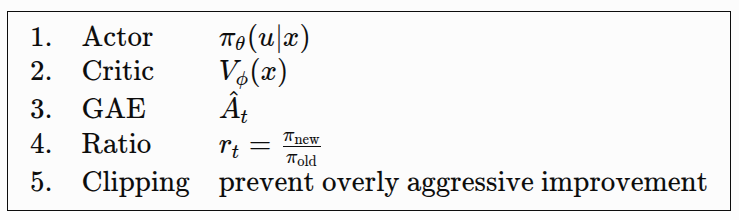